# Data Analyst Agent - Notebook d'analyse

Ce notebook permet d'exécuter la pipeline complète d'analyse de données de manière interactive.

## Prérequis

Avant de lancer ce notebook, assurez-vous que:
1. Vous avez créé un fichier `.env` avec votre clé API OpenAI:
   ```bash
   cp .env.example .env
   # Puis éditez .env pour ajouter votre clé:
   # OPENAI_API_KEY=sk-votre_cle_ici
   ```
2. Les dépendances sont installées: `pip install -r requirements.txt`

## Configuration

Configurez les paramètres ci-dessous avant d'exécuter les cellules.

In [1]:
# ============================================
# CONFIGURATION
# ============================================

# Chemin vers le fichier CSV à analyser
# Modifier cette variable pour pointer vers votre fichier
DATA_PATH = "data/test_data.csv"

# Répertoire de sortie
OUTPUT_DIR = "outputs"

# Fichier de configuration
CONFIG_PATH = "config.yaml"

# Activer/désactiver le mode LLM (nécessite une clé API OpenAI valide)
LLM_ENABLED = True

# Niveau de logging (DEBUG, INFO, WARNING, ERROR)
LOG_LEVEL = "INFO"

print(f"Configuration chargée:")
print(f"  - DATA_PATH: {DATA_PATH}")
print(f"  - OUTPUT_DIR: {OUTPUT_DIR}")
print(f"  - CONFIG_PATH: {CONFIG_PATH}")
print(f"  - LLM_ENABLED: {LLM_ENABLED}")

Configuration chargée:
  - DATA_PATH: data/test_data.csv
  - OUTPUT_DIR: outputs
  - CONFIG_PATH: config.yaml
  - LLM_ENABLED: True


## 1. Import des modules et chargement de la configuration

Importation des modules nécessaires et chargement de la configuration.

In [2]:
# ============================================
# IMPORTS ET CONFIGURATION
# ============================================

import os
import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Trouver le répertoire racine du projet
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

sys.path.insert(0, str(project_root))

print(f"Répertoire notebook: {current_dir}")
print(f"Racine du projet: {project_root}")

# Import des modules
from src.config_env import load_dotenv_config, get_openai_key, is_llm_enabled
from src.ingest import load_data
from src.clean import clean_data
from src.analyze import analyze_data
from src.viz import generate_viz, create_histogram, create_boxplot, create_bar_chart
from src.report import generate_report
import pandas as pd
import numpy as np
import yaml
import logging

# Configuration du logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Charger la configuration YAML
config_path = project_root / 'config.yaml'
if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Configuration chargée depuis: {config_path}")
else:
    config = {
        "data": {"output_dir": "outputs"},
        "llm": {"enabled": True},
        "cleaning": {"handle_duplicates": True, "handle_outliers": True},
        "visualization": {"style": "default"}
    }
    print(f"Configuration par défaut utilisée")

# Charger .env
load_dotenv_config()

# Vérifier la configuration LLM
llm_config = config.get('llm', {})
llm_config['enabled'] = True  # On force à True pour tester

if llm_config.get('enabled', False):
    try:
        get_openai_key()
        print("LLM activé - clé API OpenAI trouvée")
    except ValueError as e:
        print(f"LLM désactivé - clé API non disponible: {str(e)[:100]}...")
        llm_config['enabled'] = False
else:
    print("LLM désactivé dans la configuration")

print(f"Configuration finale - LLM: {'activé' if llm_config.get('enabled') else 'désactivé'}")


Répertoire notebook: c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\notebooks
Racine du projet: c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet


2026-02-27 13:58:01,792 - src.config_env - INFO - Configuration chargée depuis: c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\.env
2026-02-27 13:58:01,793 - src.config_env - INFO - Clé API OpenAI chargée depuis environment


Configuration chargée depuis: c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\config.yaml
LLM activé - clé API OpenAI trouvée
Configuration finale - LLM: activé


## 2. Chargement des données (Ingestion)

Charge le fichier CSV avec détection automatique du séparateur et de l'encodage.

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "test_data.csv"

print("DATA_PATH =", DATA_PATH)
print("Exists =", DATA_PATH.exists())

DATA_PATH = c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\data\test_data.csv
Exists = True


In [4]:
# ============================================
# ÉTAPE 1: INGESTION
# ============================================

print("=" * 60)
print("ÉTAPE 1: Ingestion des données")
print("=" * 60)

# Charger les données
df, ingestion_meta = load_data(
    str(DATA_PATH),
    encoding=config.get('data', {}).get('encoding'),
    separator=config.get('data', {}).get('separator'),
    skiprows=config.get('data', {}).get('skip_rows', 0)
)

print(f"\n✅ Données chargées avec succès!")
print(f"  - Lignes: {len(df)}")
print(f"  - Colonnes: {len(df.columns)}")
print(f"  - Fichier: {ingestion_meta.get('filename', 'N/A')}")
print(f"  - Encoding: {ingestion_meta.get('encoding_used', 'N/A')}")
print(f"  - Séparateur: {ingestion_meta.get('separator_used', 'N/A')}")

# Afficher les colonnes
print(f"\nColonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

2026-02-27 13:58:01,831 - src.ingest - INFO - Chargement du fichier CSV: c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\data\test_data.csv
2026-02-27 13:58:01,834 - src.ingest - INFO - Fichier chargé: 10 lignes, 6 colonnes
2026-02-27 13:58:01,835 - src.ingest - INFO - Colonnes: ['nom', 'ge', 'ville', 'revenu', 'score', 'date']


ÉTAPE 1: Ingestion des données

✅ Données chargées avec succès!
  - Lignes: 10
  - Colonnes: 6
  - Fichier: test_data.csv
  - Encoding: utf-8
  - Séparateur: ,

Colonnes disponibles:
  1. nom
  2. ge
  3. ville
  4. revenu
  5. score
  6. date


## 3. Nettoyage des données

Nettoie les données avec inférence de types, gestion des NA, suppression des doublons et détection des outliers.

In [5]:
# ============================================
# ÉTAPE 2: NETTOYAGE
# ============================================

print("=" * 60)
print("ÉTAPE 2: Nettoyage des données")
print("=" * 60)

# Configuration du nettoyage
cleaning_config = config.get('cleaning', {})

df_clean, data_quality = clean_data(
    df,
    handle_duplicates=cleaning_config.get('handle_duplicates', True),
    handle_outliers=cleaning_config.get('handle_outliers', True),
    winsorize=cleaning_config.get('winsorize', False),
    normalize_strings=cleaning_config.get('normalize_strings', True),
    infer_types=cleaning_config.get('infer_types', True)
)

print(f"\n✅ Nettoyage complété!")
print(f"  - Lignes avant: {len(df)}")
print(f"  - Lignes après: {len(df_clean)}")
print(f"  - Lignes supprimées: {len(df) - len(df_clean)}")

# Afficher les modifications
type_inference = data_quality.get('type_inference', {})
print(f"\nInférence de types:")
type_counts = {}
for col, info in type_inference.items():
    t = info.get('type', 'unknown')
    type_counts[t] = type_counts.get(t, 0) + 1
for t, count in type_counts.items():
    print(f"  - {t}: {count} colonnes")

# Afficher la qualité
before_na = data_quality.get('before', {}).get('na_count', 0)
after_na = data_quality.get('after', {}).get('na_count', 0)
print(f"\nValeurs manquantes:")
print(f"  - Avant nettoyage: {before_na}")
print(f"  - Après nettoyage: {after_na}")
print(f"  - Réduction: {before_na - after_na}")

2026-02-27 13:58:01,850 - src.clean - INFO - Début du nettoyage des données
2026-02-27 13:58:01,850 - src.clean - INFO - Shape initiale: (10, 6)
2026-02-27 13:58:01,868 - src.clean - INFO - Types inferes: 6 colonnes
2026-02-27 13:58:01,869 - src.clean - INFO - Inférence de types complétée
2026-02-27 13:58:01,875 - src.clean - INFO - Valeurs manquantes gérées: 6 colonnes
2026-02-27 13:58:01,876 - src.clean - INFO - Doublons supprimés: 0 lignes
2026-02-27 13:58:01,880 - src.clean - INFO - Strings normalisés: 3 colonnes
2026-02-27 13:58:01,881 - src.clean - INFO - Normalisation des strings complétée
2026-02-27 13:58:01,884 - src.clean - INFO - Outliers détectés: 3 colonnes
2026-02-27 13:58:01,887 - src.clean - INFO - Nettoyage termine: (10, 6)


ÉTAPE 2: Nettoyage des données

✅ Nettoyage complété!
  - Lignes avant: 10
  - Lignes après: 10
  - Lignes supprimées: 0

Inférence de types:
  - categorical: 2 colonnes
  - numeric: 3 colonnes
  - datetime: 1 colonnes

Valeurs manquantes:
  - Avant nettoyage: 2
  - Après nettoyage: 0
  - Réduction: 2


## 4. Analyse des données

Génère un profil complet du dataset avec:
- Profil des données (shape, types, missingness)
- Statistiques numériques et catégorielles
- Corrélations
- Insights (LLM ou rule-based)
- Suggestions de visualisation

In [6]:
# ============================================
# ÉTAPE 3: ANALYSE
# ============================================

print("=" * 60)
print("ÉTAPE 3: Analyse des données")
print("=" * 60)

# Exécuter l'analyse
analysis_summary, insights, viz_suggestions = analyze_data(
    df_clean,
    llm_config=llm_config
)

print(f"\n✅ Analyse complétée!")
print(f"  - Lignes: {analysis_summary.get('shape', {}).get('rows', 'N/A')}")
print(f"  - Colonnes: {analysis_summary.get('shape', {}).get('columns', 'N/A')}")
print(f"  - Insights générés: {len(insights)}")
print(f"  - Visualisations suggérées: {len(viz_suggestions)}")

# Afficher les types de colonnes
column_types = analysis_summary.get('column_types', {})
print(f"\nTypes de colonnes:")
for col, info in list(column_types.items())[:10]:
    print(f"  - {col}: {info.get('type', 'unknown')} ({info.get('dtype', 'unknown')})")

2026-02-27 13:58:01,899 - src.analyze - INFO - Début de l'analyse des données
2026-02-27 13:58:01,900 - src.analyze - INFO - Shape du DataFrame: (10, 6)
2026-02-27 13:58:01,913 - src.analyze - INFO - Stats numériques: 3 colonnes
2026-02-27 13:58:01,916 - src.analyze - INFO - Stats catégorielles: 3 colonnes
2026-02-27 13:58:01,918 - src.analyze - INFO - Corrélations: 1 paires fortes
2026-02-27 13:58:01,920 - src.analyze - INFO - Génération d'insights rule-based
2026-02-27 13:58:01,922 - src.analyze - INFO - Analyse complétée: 3 insights, 10 visualisations suggérées


ÉTAPE 3: Analyse des données

✅ Analyse complétée!
  - Lignes: 10
  - Colonnes: 6
  - Insights générés: 3
  - Visualisations suggérées: 10

Types de colonnes:
  - nom: categorical (str)
  - ge: numeric (float64)
  - ville: categorical (str)
  - revenu: numeric (int64)
  - score: numeric (float64)
  - date: categorical (str)


## 5. Aperçu des données et qualité

Affiche un aperçu du dataframe nettoyé et un résumé de la qualité des données.

In [7]:
# ============================================
# APERÇU DES DONNÉES
# ============================================

print("=" * 60)
print("APERÇU DES DONNÉES")
print("=" * 60)

# Afficher les premières lignes
print("\nPremières lignes du dataset:")
df_clean.head(10)

APERÇU DES DONNÉES

Premières lignes du dataset:


,nom,ge,ville,revenu,score,date
0,Alice,25.0,Paris,50000,85.0,2024-01-15
1,Bob,30.0,Lyon,60000,90.0,2024-01-16
2,Charlie,35.0,Paris,75000,78.0,2024-01-17
3,David,40.0,Marseille,80000,92.0,2024-01-18
4,Eve,25.0,Paris,50000,85.0,2024-01-19
5,Frank,30.0,Lyon,55000,88.0,2024-01-20
6,Grace,30.0,Paris,62000,88.0,2024-01-21
7,Henry,35.0,Marseille,70000,95.0,2024-01-22
8,Ivan,40.0,Paris,85000,91.0,2024-01-23
9,Julie,25.0,Lyon,48000,87.0,2024-01-24


In [8]:
# ============================================
# RÉSUMÉ DE LA QUALITÉ DES DONNÉES
# ============================================

missingness = analysis_summary.get('missingness', {})
print("=" * 60)
print("RÉSUMÉ DE LA QUALITÉ DES DONNÉES")
print("=" * 60)

print(f"\nScore de qualité: {100 - missingness.get('percentage_na', 0):.1f}%")
print(f"\n| Métrique | Valeur |")
print(f"|----------|--------|")
print(f"| Lignes | {len(df_clean)} |")
print(f"| Colonnes | {len(df_clean.columns)} |")
print(f"| Total valeurs manquantes | {missingness.get('total_na', 0)} |")
print(f"| % valeurs manquantes | {missingness.get('percentage_na', 0):.1f}% |")

# Colonnes avec NA
columns_info = analysis_summary.get('column_types', {})
cols_with_na = [(col, info.get('missing_pct', 0)) for col, info in columns_info.items() if info.get('missing_pct', 0) > 0]

if cols_with_na:
    print(f"\nColonnes avec valeurs manquantes:")
    for col, pct in sorted(cols_with_na, key=lambda x: -x[1]):
        print(f"  - {col}: {pct:.1f}%")

# Corrélations fortes
strong_corr = analysis_summary.get('correlations', {}).get('strong_correlations', [])
if strong_corr:
    print(f"\nCorrélations fortes (>0.7):")
    for corr in strong_corr[:5]:
        print(f"  - {corr['col1']} vs {corr['col2']}: {corr['correlation']:.3f}")

RÉSUMÉ DE LA QUALITÉ DES DONNÉES

Score de qualité: 100.0%

| Métrique | Valeur |
|----------|--------|
| Lignes | 10 |
| Colonnes | 6 |
| Total valeurs manquantes | 0 |
| % valeurs manquantes | 0.0% |

Corrélations fortes (>0.7):
  - ge vs revenu: 0.981


## 6. Insights générés

Affiche les insights générés par l'analyse (LLM ou rule-based).

In [9]:
# ============================================
# INSIGHTS
# ============================================

print("=" * 60)
print("INSIGHTS GÉNÉRÉS")
print("=" * 60)

if insights:
    print(f"\n{len(insights)} insights trouvés:\n")
    for i, insight in enumerate(insights, 1):
        title = insight.get('title', 'Sans titre')
        description = insight.get('description', insight.get('text', ''))
        severity = insight.get('severity', 'info')
        
        # Emoji selon la sévérité
        if severity == 'high':
            emoji = '🔴'
        elif severity == 'medium':
            emoji = '🟡'
        else:
            emoji = '🔵'
        
        print(f"{emoji} **Insight {i}:** {title}")
        print(f"   {description}")
        
        # Recommendation si présente
        recommendation = insight.get('recommendation', '')
        if recommendation:
            print(f"   *Recommandation: {recommendation}*")
        print()
else:
    print("\nAucun insight généré.")

INSIGHTS GÉNÉRÉS

3 insights trouvés:

🔵 **Insight 1:** Dataset de petite taille
   Le dataset contient seulement 10 lignes. Les analyses statistiques peuvent être limitées.
   *Recommandation: Considérez collecter plus de données ou utiliser des techniques d'analyse adaptées aux petits échantillons.*

🔵 **Insight 2:** Colonne nom très unique
   La colonne nom a 10 valeurs uniques sur 10 lignes (100.0%).

🔵 **Insight 3:** Colonne date très unique
   La colonne date a 10 valeurs uniques sur 10 lignes (100.0%).



## 7. Génération des visualisations

Génère les visualisations et les affiche inline dans le notebook.

In [10]:
# ============================================
# ÉTAPE 4: VISUALISATIONS
# ============================================

print("=" * 60)
print("ÉTAPE 4: Génération des visualisations")
print("=" * 60)

# Créer le répertoire de sortie s'il n'existe pas
from pathlib import Path
output_path = Path(OUTPUT_DIR)
output_path.mkdir(parents=True, exist_ok=True)
(output_path / "figures").mkdir(parents=True, exist_ok=True)

# Générer les visualisations
figures = generate_viz(
    df_clean,
    output_dir=OUTPUT_DIR,
    viz_suggestions=viz_suggestions,
    prefix="analysis"
)

total_viz = sum(len(v) for v in figures.values())
print(f"\n✅ Visualisations générées: {total_viz} fichiers")
print(f"   Répertoire: {output_path / 'figures'}")

2026-02-27 13:58:01,995 - src.viz - INFO - Colonnes disponibles: num=3, cat=3, date=0



ÉTAPE 4: Génération des visualisations


2026-02-27 13:58:02,124 - src.viz - INFO - Histogramme sauvegardé: outputs\figures\analysis_ge_hist.png
2026-02-27 13:58:02,192 - src.viz - INFO - Boxplot sauvegardé: outputs\figures\analysis_ge_box.png
2026-02-27 13:58:02,306 - src.viz - INFO - Histogramme sauvegardé: outputs\figures\analysis_revenu_hist.png
2026-02-27 13:58:02,378 - src.viz - INFO - Boxplot sauvegardé: outputs\figures\analysis_revenu_box.png
2026-02-27 13:58:02,486 - src.viz - INFO - Histogramme sauvegardé: outputs\figures\analysis_score_hist.png
2026-02-27 13:58:02,553 - src.viz - INFO - Boxplot sauvegardé: outputs\figures\analysis_score_box.png
2026-02-27 13:58:02,647 - src.viz - INFO - Bar chart sauvegardé: outputs\figures\analysis_nom_bar.png
2026-02-27 13:58:02,725 - src.viz - INFO - Bar chart sauvegardé: outputs\figures\analysis_ville_bar.png
2026-02-27 13:58:02,733 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should 


✅ Visualisations générées: 10 fichiers
   Répertoire: outputs\figures


AFFICHAGE DES VISUALISATIONS

Chemin du répertoire figures: c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\notebooks\outputs\figures

Fichiers trouvés: 10 images

### analysis_date_bar.png


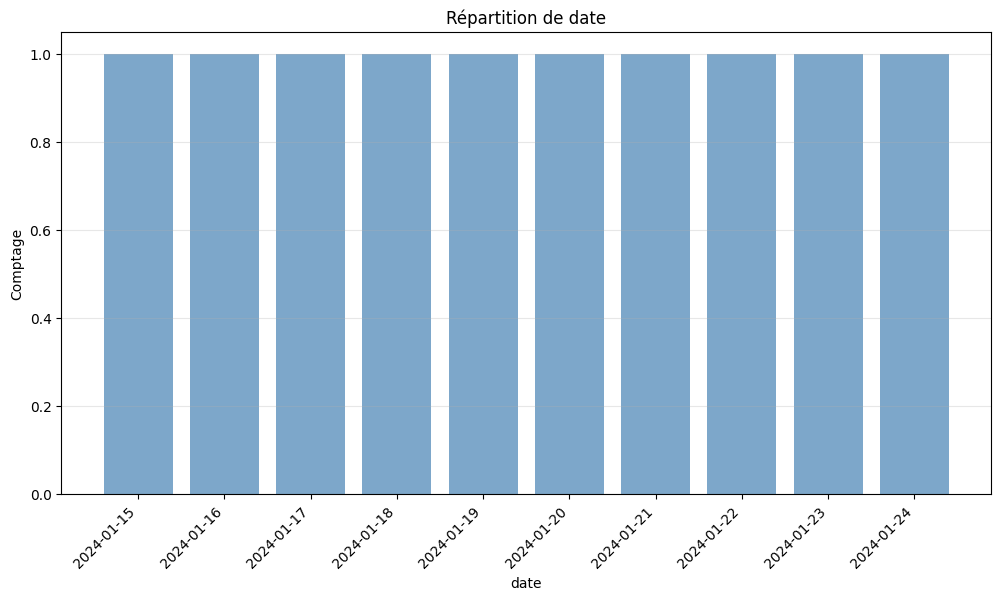


### analysis_ge_box.png


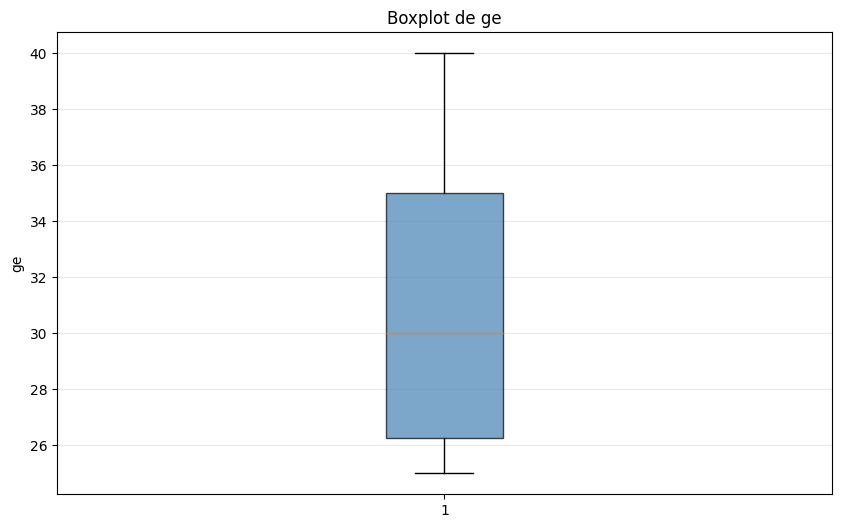


### analysis_ge_hist.png


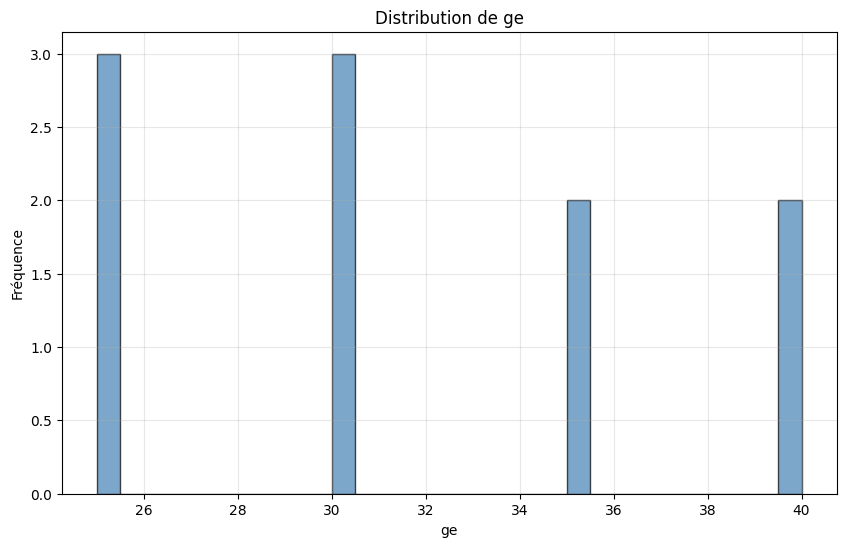


### analysis_nom_bar.png


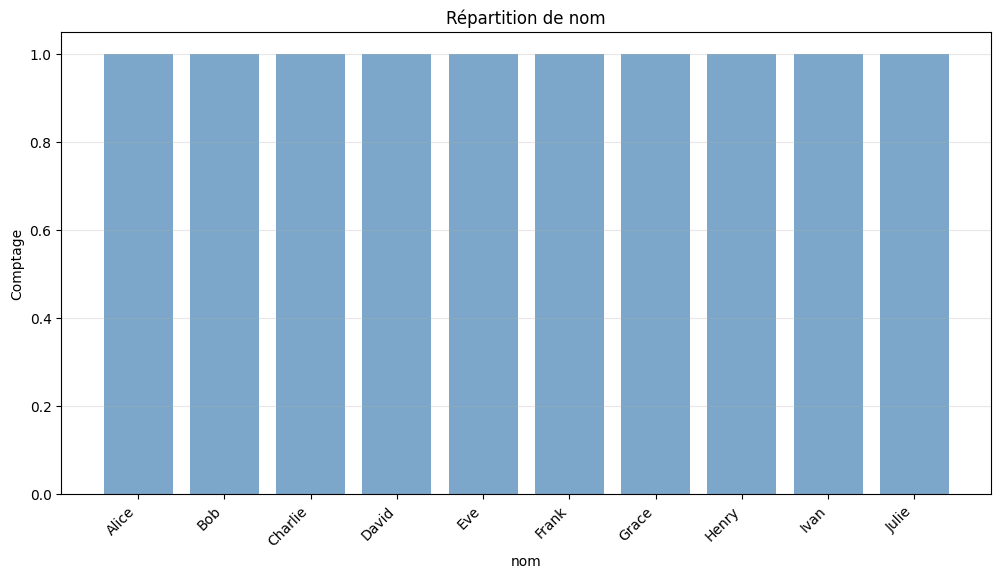


### analysis_revenu_box.png


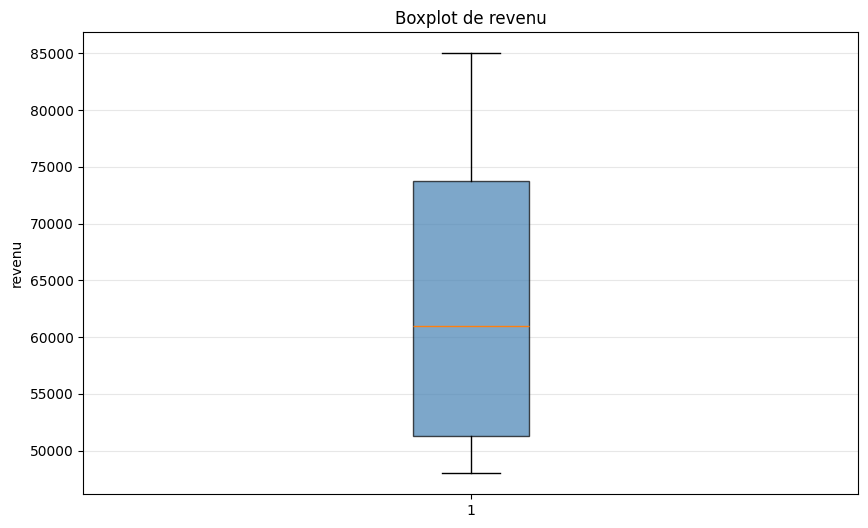


### analysis_revenu_hist.png


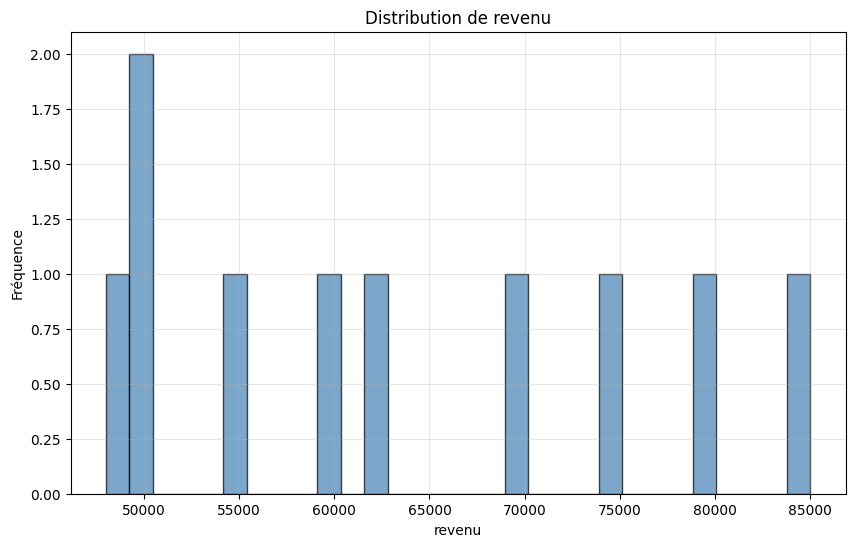


### analysis_score_box.png


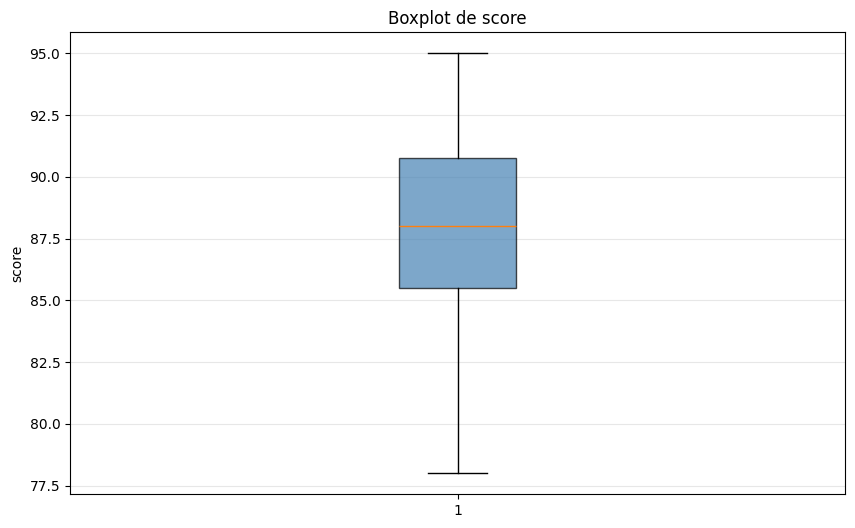


### analysis_score_hist.png


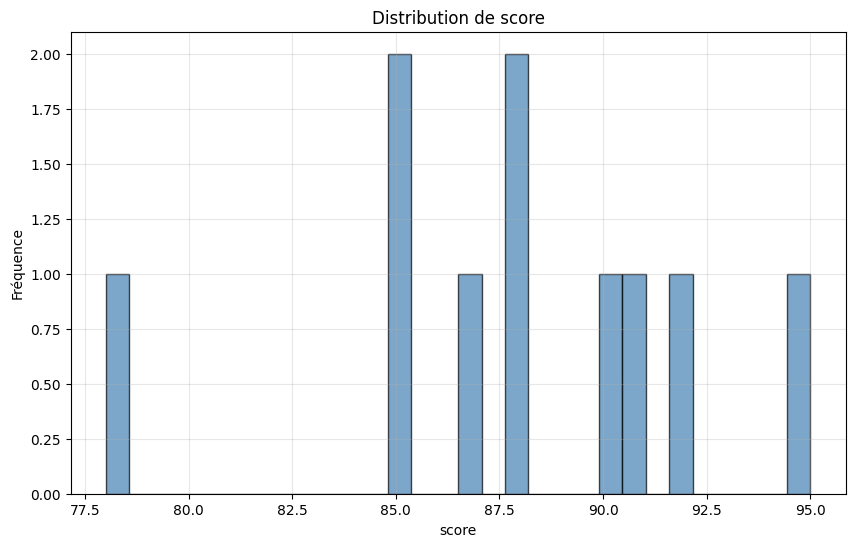


### analysis_ville_bar.png


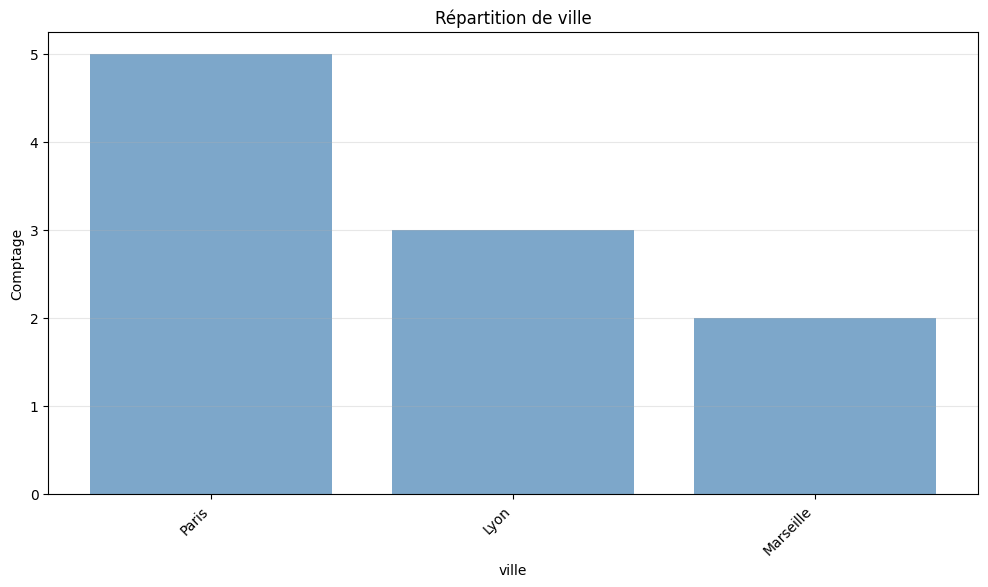


### viz_6_ge_revenu_scatter.png


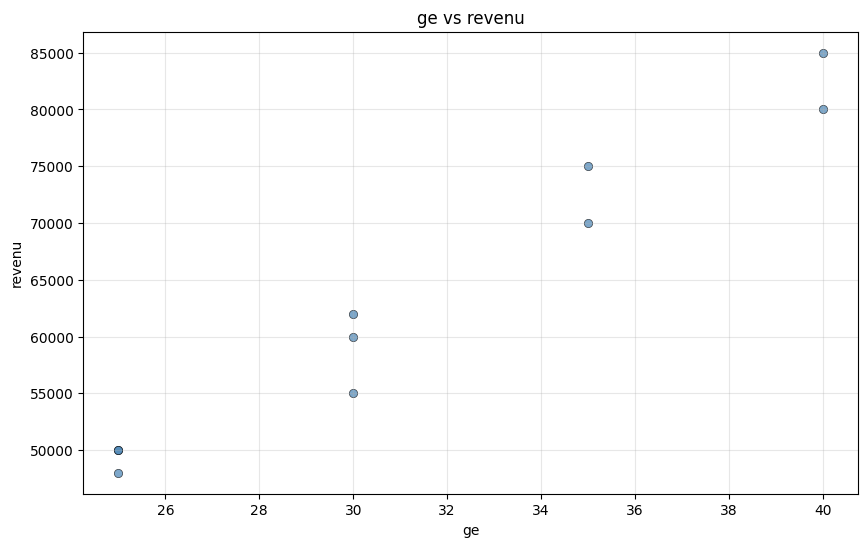

In [11]:
# ============================================
# AFFICHAGE DES VISUALISATIONS
# ============================================

from IPython.display import display, Image
from pathlib import Path

print("=" * 60)
print("AFFICHAGE DES VISUALISATIONS")
print("=" * 60)

# IMPORTANT : les figures sont dans notebooks/outputs/figures
figures_dir = Path.cwd() / "outputs" / "figures"

image_files = sorted(figures_dir.glob("*.png"))

print(f"\nChemin du répertoire figures: {figures_dir}")
print(f"\nFichiers trouvés: {len(image_files)} images")

if image_files:
    for img_path in image_files:
        print(f"\n### {img_path.name}")
        display(Image(filename=str(img_path)))
else:
    print(f"\nAucune image trouvée dans {figures_dir}")

## 8. Génération du rapport

Génère le rapport Markdown final avec tous les éléments.

In [12]:
# ============================================
# ÉTAPE 5: RAPPORT
# ============================================

from pathlib import Path

print("=" * 60)
print("ÉTAPE 5: Génération du rapport")
print("=" * 60)

# Racine du projet (car notebook dans /notebooks)
PROJECT_ROOT = Path.cwd().parent

report_path = generate_report(
    analysis_summary=analysis_summary,
    figures_dir=Path.cwd() / OUTPUT_DIR / "figures",  # figures dans notebooks/outputs
    llm_config=llm_config
)

print(f"\n✅ Rapport généré: {report_path}")

# Chemin absolu (robuste)
report_path = PROJECT_ROOT / report_path

print(f"\nChemin du rapport:")
print(report_path)

print(f"\nDossier figures:")
print(Path.cwd() / OUTPUT_DIR / "figures")

2026-02-27 13:58:03,101 - src.report - INFO - Rapport généré: outputs\report.md


ÉTAPE 5: Génération du rapport

✅ Rapport généré: outputs\report.md

Chemin du rapport:
c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\outputs\report.md

Dossier figures:
c:\Users\Selyan\Desktop\selyan_cours\ia generative2\pangou.abadou\PANGOUGravie.ABADOUSelyan.projet\notebooks\outputs\figures


## 9. Sauvegarde du résumé complet

Sauvegarde un fichier JSON complet avec tous les résultats.

In [ ]:
# ============================================
# QUESTIONS/RÉPONSES (QA)
# ============================================

print("=" * 60)
print("QUESTIONS/RÉPONSES (QA)")
print("=" * 60)

# Trouver le répertoire racine du projet
current_dir = Path.cwd()
project_root = current_dir.parent if (current_dir / 'notebooks').exists() else current_dir
sys.path.insert(0, str(project_root))

from src.qa import DataQA

# Variable de question
QUESTION = "Valeurs plus fréquentes de ville"

# Créer le système QA
qa = DataQA(df_clean, config)
print(f"Mode QA: {'LLM' if qa.llm_enabled else 'rule-based'}")

# Poser la question
answer = qa.answer(QUESTION, return_tool_results=True)

print(f"\nQuestion: {QUESTION}")
print(f"Réponse: {answer['response']}")
print(f"Mode utilisé: {answer['mode']}")

if 'tool_results' in answer and answer['tool_results']:
    print(f"\nOutils utilisés:")
    for tool_name, result, success in answer['tool_results']:
        status = "SUCCESS" if success else f"ERROR: {result.get('error', 'unknown')}"
        print(f"  - {tool_name}: {status}")

# Boucle interactive
print("\n" + "=" * 60)
print("BOUCLE INTERACTIVE - Posez vos propres questions")
print("=" * 60)
print("Tapez exit pour quitter")

while True:
    try:
        user_question = input("\nVotre question : ")
        if user_question.lower().strip() in ['exit', 'quit', 'q']:
            print("Au revoir!")
            break
        if not user_question.strip():
            continue
        answer = qa.answer(user_question, return_tool_results=True)
        print(f"Réponse: {answer['response']}")
        print(f"Mode: {answer['mode']}")
    except EOFError:
        break
    except KeyboardInterrupt:
        print("\nInterrompu.")
        break


2026-02-27 13:58:03,126 - src.qa - INFO - DataQA initialisé (rule-based): 6 colonnes


QUESTIONS/RÉPONSES (QA)
Mode QA: rule-based

Question: Valeurs plus fréquentes de ville
Réponse: Valeurs principales: Alice
Mode utilisé: rule-based

BOUCLE INTERACTIVE - Posez vos propres questions
Tapez exit pour quitter


In [ ]:
# ============================================
# SAUVEGARDE DU RÉSUMÉ COMPLET
# ============================================

print("=" * 60)
print("Sauvegarde du résumé complet")
print("=" * 60)

# Créer le résumé complet
summary = {
    "metadata": {
        "input_file": DATA_PATH,
        "output_dir": OUTPUT_DIR,
        "notebook_execution": True,
        "timestamp": pd.Timestamp.now().isoformat()
    },
    "ingestion_meta": ingestion_meta,
    "data_quality": data_quality,
    "analysis_summary": analysis_summary,
    "figures": figures,
    "insights": insights,
    "viz_suggestions": viz_suggestions
}

# Sauvegarder
import json
summary_path = Path(OUTPUT_DIR) / "summary.json"
with open(summary_path, 'w', encoding='utf-8') as f:
    def json_serializer(obj):
        if isinstance(obj, Path):
            return str(obj)
        elif hasattr(obj, 'tolist'):
            return obj.tolist()
        elif isinstance(obj, (pd.Timestamp, pd.Period)):
            return str(obj)
        elif isinstance(obj, (pd.Series, pd.DataFrame)):
            return obj.to_dict()
        return str(obj)
    
    json.dump(summary, f, indent=2, default=json_serializer)

print(f"\n✅ Résumé complet sauvegardé: {summary_path}")

# Afficher un extrait du résumé
print(f"\nExtrait du résumé:")
print(f"  - Lignes: {summary['analysis_summary']['shape']['rows']}")
print(f"  - Colonnes: {summary['analysis_summary']['shape']['columns']}")
print(f"  - Insights: {len(summary['insights'])}")
print(f"  - Visualisations: {sum(len(v) for v in summary['figures'].values())}")

## ✅ Pipeline complétée!

La pipeline d'analyse est terminée. Voici un récapitulatif des sorties générées:

```
outputs/
├── cleaned.csv           # Données nettoyées
├── summary.json          # Résumé complet (JSON)
├── report.md             # Rapport Markdown
├── execution_results.json
└── figures/
    ├── analysis_*_hist.png
    ├── analysis_*_box.png
    ├── analysis_*_bar.png
    └── ...
```

### Prochaines étapes

1. Consultez le rapport Markdown: `outputs/report.md`
2. Consultez le résumé JSON: `outputs/summary.json`
3. Consultez les visualisations dans: `outputs/figures/`
4. Exécutez le notebook avec un autre dataset en modifiant `DATA_PATH`

---
*Notebook généré par Data Analyst Agent*